In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from constant import LIFESNAPS_PATH, EXPS_PATH

In [8]:
def get_exp_path(dataset, exp, mode, norm_str, seq_enc, tab_enc, unlabel_ratio, label_ratio, exclude, fold, seed):
    run_name = f'{dataset}/{exp}/{mode}/{norm_str}/seq:{seq_enc}_tab:{tab_enc}/'
    run_name += f'unlabel_rate_{unlabel_ratio}/label_rate_{label_ratio}/{exclude}/fold_{fold}/seed_{seed}'
    return os.path.join(EXPS_PATH, run_name)

In [9]:
a = get_exp_path(
    dataset='lifesnaps',
    exp='run',
    mode='clip',
    norm_str='quantile_global',
    seq_enc='transformer',
    tab_enc='resnet',
    unlabel_ratio=1,
    label_ratio=100,
    exclude='label',
    fold=0,
    seed=0,
)
os.listdir(a)

['args.json',
 'common_fa.npy',
 'results.csv',
 'tabular_fa.npy',
 'results_lp.csv',
 'results_ft.csv']

In [17]:
def read_all_scores(dataset='lifesnaps'):
    aucs = []
    if dataset == 'lifesnaps':
        unlabel_ratio = 1
        label_ratio = 100
    elif dataset == 'pmdata':
        label_ratio = 1
        unlabel_ratio = 100
    for fold in range(5):
        for seed in range(4):
            run_dir = get_exp_path(
                dataset=dataset,
                exp='run',
                mode='clip',
                norm_str='quantile_global',
                seq_enc='transformer',
                tab_enc='resnet',
                unlabel_ratio=unlabel_ratio,
                label_ratio=label_ratio,
                exclude='label',
                fold=fold,
                seed=seed,
            )
            scores = pd.read_csv(os.path.join(run_dir, 'results_ft.csv'))
            max_score = scores['val_auc'].max()
            aucs.append(max_score)
    mu, sigma = np.mean(aucs), np.std(aucs)
    print(f'${mu*100:.2f} \pm {sigma*100:.2f}$')
    return scores

In [18]:
_ = read_all_scores(dataset='lifesnaps')
_ = read_all_scores(dataset='pmdata')

$68.63 \pm 4.81$
$73.63 \pm 3.32$


In [3]:
lifesnaps_results = pd.read_csv('lifesnaps.csv')
pmdata_results = pd.read_csv('pmdata.csv')

In [4]:
def get_max_auc_val(
    res_df=lifesnaps_results,
    dataset='lifesnaps',
    mode='clip',
    stats=True,
):
    max_auc_all_arr = res_df[
        (res_df['dataset'] == dataset)
        & (res_df['exp'] == 'run')
        & (res_df['norm_type'] == 'global')
        & (res_df['scaler'] == 'quantile')
        & (res_df['seq_enc'] == 'transformer')
        & (res_df['tab_enc'] == 'resnet')
        & (res_df['mode'] == mode)
    ]
    # for each combination of fold and seed, get the best result in terms of max_auc_all
    max_auc_all_arr = max_auc_all_arr.groupby(['fold', 'seed'])
    # for name, group in max_auc_all_arr:
    #     print(name)
    #     print(group)
    max_auc_all_arr = max_auc_all_arr['max_auc_all'].max()
    # print(max_auc_all_arr)
    max_auc_all_arr = max_auc_all_arr.reset_index()
    # print(max_auc_all_arr)
    # compute average and std of the best results
    max_auc_all_arr = max_auc_all_arr['max_auc_all']
    if stats:
        auc_mean, auc_std = max_auc_all_arr.mean(), max_auc_all_arr.std()
        return auc_mean, auc_std
    else:
        return max_auc_all_arr

In [4]:
get_max_auc_val()

(0.7244719827586208, 0.04819697760624684)

In [5]:
def get_max_auc_val_exclude(
    res_df=lifesnaps_results,
    dataset='lifesnaps',
    mode='clip',
    exclude='label',
    stats=False,
):
    max_auc_all_arr = res_df[
        (res_df['dataset'] == dataset)
        & (res_df['exp'] == 'run')
        & (res_df['norm_type'] == 'global')
        & (res_df['scaler'] == 'quantile')
        & (res_df['seq_enc'] == 'transformer')
        & (res_df['tab_enc'] == 'resnet')
        & (res_df['mode'] == mode)
        & (res_df['exclude'] == exclude)
    ]
    # for each combination of fold and seed, get the best result in terms of max_auc_all
    max_auc_all_arr = max_auc_all_arr.groupby(['fold', 'seed'])
    max_auc_all_arr = max_auc_all_arr['max_auc_all'].max()
    max_auc_all_arr = max_auc_all_arr.reset_index()
    # compute average and std of the best results
    max_auc_all_arr = max_auc_all_arr['max_auc_all']
    if stats:
        auc_mean, auc_std = max_auc_all_arr.mean(), max_auc_all_arr.std()
        return auc_mean, auc_std
    else:
        return max_auc_all_arr

In [6]:
print(get_max_auc_val_exclude(lifesnaps_results, dataset='lifesnaps', exclude='label', stats=True))
print(get_max_auc_val_exclude(lifesnaps_results, dataset='lifesnaps', exclude='all', stats=True))

(0.7100502873563218, 0.0574322401348492)
(0.7123024425287356, 0.05034567353023981)


In [7]:
print(get_max_auc_val_exclude(pmdata_results, dataset='pmdata', exclude='label', stats=True))
print(get_max_auc_val_exclude(pmdata_results, dataset='pmdata', exclude='all', stats=True))

(0.8087898261648301, 0.017850845371523545)
(0.8005492345039492, 0.02346179896685992)


In [8]:
pmdata_results[pmdata_results['mode'] == 'sup']

,dataset,exp,mode,n_epochs,lr,batch_size,hidden_size,n_layers,seq_enc,tab_enc,...,exclude,unlabel_ratio,label_ratio,seed,scaler,norm_type,max_auc,max_auc_lp,max_auc_ft,max_auc_all
0,pmdata,run,sup,300,0.0001,512,64,3,transformer,resnet,...,all,0.0,1.0,0,quantile,global,0.807844,NaN,NaN,0.807844
1,pmdata,run,sup,300,0.0001,512,64,3,transformer,resnet,...,all,0.0,1.0,1,quantile,global,0.803875,NaN,NaN,0.803875
2,pmdata,run,sup,300,0.0001,512,64,3,transformer,resnet,...,all,0.0,1.0,2,quantile,global,0.814886,NaN,NaN,0.814886
3,pmdata,run,sup,300,0.0001,512,64,3,transformer,resnet,...,all,0.0,1.0,3,quantile,global,0.817431,NaN,NaN,0.817431
4,pmdata,run,sup,300,0.0001,512,64,3,transformer,resnet,...,all,0.0,1.0,0,quantile,global,0.826466,NaN,NaN,0.826466
5,pmdata,run,sup,300,0.0001,512,64,3,transformer,resnet,...,all,0.0,1.0,1,quantile,global,0.854872,NaN,NaN,0.854872
6,pmdata,run,sup,300,0.0001,512,64,3,transformer,resnet,...,all,0.0,1.0,2,quantile,global,0.817713,NaN,NaN,0.817713
7,pmdata,run,sup,300,0.0001,512,64,3,transformer,resnet,...,all,0.0,1.0,3,quantile,global,0.817547,NaN,NaN,0.817547
8,pmdata,run,sup,300,0.0001,512,64,3,transformer,resnet,...,all,0.0,1.0,0,quantile,global,0.808592,NaN,NaN,0.808592
9,pmdata,run,sup,300,0.0001,512,64,3,transformer,resnet,...,all,0.0,1.0,1,quantile,global,0.819876,NaN,NaN,0.819876


In [9]:
def get_max_auc_val_by_ratio(
    res_df=lifesnaps_results,
    dataset='lifesnaps',
    mode='clip',
    exclude='label',
    label_ratio=1.0,
    unlabel_ratio=1.0,
    stats=False,
):
    max_auc_all_arr = res_df[
        (res_df['dataset'] == dataset)
        & (res_df['exp'] == 'run')
        & (res_df['norm_type'] == 'global')
        & (res_df['scaler'] == 'quantile')
        & (res_df['seq_enc'] == 'transformer')
        & (res_df['tab_enc'] == 'resnet')
        & (res_df['mode'] == mode)
        & (res_df['exclude'] == exclude)
        & (res_df['label_ratio'] == label_ratio)
        & (res_df['unlabel_ratio'] == unlabel_ratio)
    ]
    # for each combination of fold and seed, get the best result in terms of max_auc_all
    max_auc_all_arr = max_auc_all_arr['max_auc_all']
    if stats:
        auc_mean, auc_std = max_auc_all_arr.mean(), max_auc_all_arr.std()
        return auc_mean, auc_std
    else:
        return max_auc_all_arr

In [10]:
lifesnaps_dict = {}
for exclude in ['label', 'all']:
    lifesnaps_dict[exclude] = {}
    for i in [0.1, 0.5, 1.0]:
        mean, std = get_max_auc_val_by_ratio(
            res_df=lifesnaps_results,
            dataset='lifesnaps',
            mode='clip',
            exclude=exclude,
            label_ratio=1.0,
            unlabel_ratio=i,
            stats=True,
        )
        print(f'lifesnaps, exclude={exclude}, label_ratio={i}, mean={mean}, std={std}')
        lifesnaps_dict[exclude][i] = (mean, std)
    print()

lifesnaps, exclude=label, label_ratio=0.1, mean=0.6840014367816092, std=0.055137675219040595
lifesnaps, exclude=label, label_ratio=0.5, mean=0.6761494252873563, std=0.05452715974997035
lifesnaps, exclude=label, label_ratio=1.0, mean=0.6762535919540229, std=0.07075797792753212

lifesnaps, exclude=all, label_ratio=0.1, mean=0.6850251436781608, std=0.05330103811331804
lifesnaps, exclude=all, label_ratio=0.5, mean=0.6835452586206896, std=0.05096327289115698
lifesnaps, exclude=all, label_ratio=1.0, mean=0.693121408045977, std=0.06425702456510439



In [14]:
pmdata_dict = {}
for exclude in ['label']:
    pmdata_dict[exclude] = {}
    for i in [0.1, 0.5, 1.0]:
        arr = get_max_auc_val_by_ratio(
            res_df=pmdata_results,
            dataset='pmdata',
            mode='clip',
            exclude=exclude,
            label_ratio=i,
            unlabel_ratio=1.0,
            stats=True,
        )
        pmdata_dict[exclude][i] = arr
    print()

In [15]:
from scipy.stats import tukey_hsd

In [16]:
res = tukey_hsd(
    pmdata_dict['label'][0.1],
    pmdata_dict['label'][0.5],
    pmdata_dict['label'][1.0],
)

In [17]:
print(res)

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.009     1.000    -2.257     2.240
 (0 - 2)     -0.017     0.999    -2.265     2.232
 (1 - 0)      0.009     1.000    -2.240     2.257
 (1 - 2)     -0.008     1.000    -2.256     2.240
 (2 - 0)      0.017     0.999    -2.232     2.265
 (2 - 1)      0.008     1.000    -2.240     2.256



In [60]:
lifesnaps_dict

{'label': {0.1: (0.6840014367816092, 0.055137675219040595),
  0.5: (0.6761494252873563, 0.05452715974997035),
  1.0: (0.6762535919540229, 0.07075797792753212)},
 'all': {0.1: (0.6850251436781608, 0.05330103811331804),
  0.5: (0.6835452586206896, 0.05096327289115698),
  1.0: (0.693121408045977, 0.06425702456510439)}}

In [61]:
pmdata_dict

{'label': {0.1: (0.7660790676032404, 0.026721581222528757),
  0.5: (0.7845389835030963, 0.025306169077451812),
  1.0: (0.8047363392047012, 0.021168949576457142)},
 'all': {0.1: (0.7558062781480708, 0.02975006991471631),
  0.5: (0.7777829412598571, 0.02525165140606079),
  1.0: (0.797305224915717, 0.026904591280433977)}}

[0.7660790676032404, 0.7845389835030963, 0.8047363392047012] [0.026721581222528757, 0.025306169077451812, 0.021168949576457142]
[0.7558062781480708, 0.7777829412598571, 0.797305224915717] [0.02975006991471631, 0.02525165140606079, 0.026904591280433977]


Text(0.5, 1.0, 'Test AUC versus Rate of Used Data for Pretraining (PMData)')

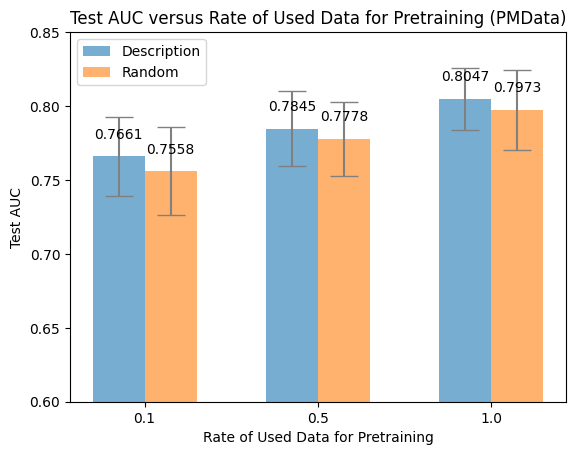

In [130]:
fig, ax = plt.subplots()

categories = list(pmdata_dict.keys())

desc_cat = pmdata_dict['label']
nons_cat = pmdata_dict['all']

desc_means = [desc_cat[0] for desc_cat in desc_cat.values()]
desc_stds = [desc_cat[1] for desc_cat in desc_cat.values()]

nons_means = [nons_cat[0] for nons_cat in nons_cat.values()]
nons_stds = [nons_cat[1] for nons_cat in nons_cat.values()]

print(desc_means, desc_stds)

print(nons_means, nons_stds)

ind = np.arange(len(desc_means))
width = 0.3   

ax.bar(ind, desc_means, width, yerr=desc_stds, alpha=0.6, ecolor='gray', capsize=10, label='Description')
ax.bar(ind + width, nons_means, width, yerr=nons_stds, alpha=0.6, ecolor='gray', capsize=10, label='Random')
ax.set_xticks(ind + width / 2)
ax.set_xticklabels(list(desc_cat.keys()))

for i, v in enumerate(desc_means):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

for i, v in enumerate(nons_means):
    ax.text(i + width, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

ax.set_ylim([0.60, 0.85])
ax.legend()

ax.set_xlabel('Rate of Used Data for Pretraining')
ax.set_ylabel('Test AUC')
ax.set_title('Test AUC versus Rate of Used Data for Pretraining (PMData)')

[0.6840014367816092, 0.6761494252873563, 0.6762535919540229] [0.055137675219040595, 0.05452715974997035, 0.07075797792753212]
[0.6850251436781608, 0.6835452586206896, 0.693121408045977] [0.05330103811331804, 0.05096327289115698, 0.06425702456510439]


Text(0.5, 1.0, 'Test AUC versus Rate of Used Data for Pretraining (LifeSnaps)')

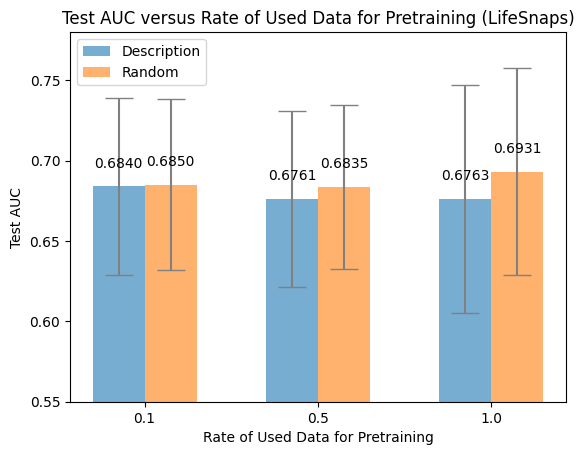

In [129]:
fig, ax = plt.subplots()

categories = list(lifesnaps_dict.keys())

desc_cat = lifesnaps_dict['label']
nons_cat = lifesnaps_dict['all']

desc_means = [desc_cat[0] for desc_cat in desc_cat.values()]
desc_stds = [desc_cat[1] for desc_cat in desc_cat.values()]
print(
    desc_means,
    desc_stds,
)

nons_means = [nons_cat[0] for nons_cat in nons_cat.values()]
nons_stds = [nons_cat[1] for nons_cat in nons_cat.values()]

print(
    nons_means,
    nons_stds,

)

ind = np.arange(len(desc_means))
width = 0.3   

ax.bar(ind, desc_means, width, yerr=desc_stds, alpha=0.6, ecolor='gray', capsize=10, label='Description')
ax.bar(ind + width, nons_means, width, yerr=nons_stds, alpha=0.6, ecolor='gray', capsize=10, label='Random')
ax.set_xticks(ind + width / 2)
ax.set_xticklabels(list(desc_cat.keys()))

for i, v in enumerate(desc_means):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

for i, v in enumerate(nons_means):
    ax.text(i + width, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

ax.set_ylim([0.55, 0.78])
ax.legend(loc='upper left')

ax.set_xlabel('Rate of Used Data for Pretraining')
ax.set_ylabel('Test AUC')
ax.set_title('Test AUC versus Rate of Used Data for Pretraining (LifeSnaps)')